In [67]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [68]:
words = open('names.txt', 'r').read().splitlines();
words[:8]

['name', 'mary', 'annie', 'anna', 'margaret', 'helen', 'elsie', 'lucy']

In [69]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0;
itos = {i:s for s,i in stoi.items()}

In [70]:
block_size = 5
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*(len(words)))
n2 = int(0.9*(len(words)))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [73]:
g = torch.Generator().manual_seed(12332)
C = torch.randn((27, 10), generator=g, requires_grad = True)
W1 = torch.randn((block_size*C.shape[1], 1000), generator=g, requires_grad = True)
b1 = torch.randn(1000, generator=g, requires_grad = True)
W2 = torch.randn((1000, 27), generator=g, requires_grad = True)
b2 = torch.randn(27, generator=g, requires_grad = True)
parameters = [C, W1, b1, W2, b2]
lr = 0.1

In [74]:
sum(p.nelement() for p in parameters)

78297

In [100]:
lri = []
losi = []
for i in range(50000):
    #minimatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    #forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(emb.shape[0], emb.shape[1]*emb.shape[2]) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    losi.append(loss.item())
    lri.append(i)
    
    #backpropagation
    for p in parameters:
        p.grad = None
    loss.backward()
    if(i==35000): lr/=10
    #train
    for p in parameters:
        p.data += -lr*p.grad

print(loss.item())

1.798250675201416


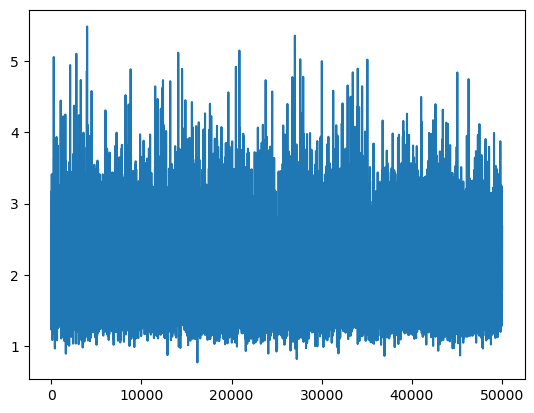

In [105]:
plt.plot(lri, losi)

In [106]:
jx = torch.randint(0, Xte.shape[0], (10000,))

In [108]:
emb = C[Xte[jx]]
h = torch.tanh(emb.view(-1, emb.shape[1]*emb.shape[2]) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yte[jx])
print(loss.item())

1.896784782409668


In [144]:
g = torch.Generator().manual_seed(123456)
for i in range(10):
    output = []
    context = [0] * block_size
    while(True):
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        output.append(ix)
        if ix==0:
            break 
    print(''.join(itos[i] for i in output))

amyrixey.
aunxor.
goris.
his.
ivin.
elino.
clayfondan.
cuknar.
euylan.
relky.


In [146]:
print(f'Number of distinct words: {len(set(words))}')

Number of distinct words: 30274
